---
title: "Forward vs. inverse parameterisation"
short_title: "02 · Forward vs. inverse"
subtitle: "One bijection, two directions — and which one you make cheap decides what the flow is good at"
description: >
  A flow is a bijection, so it runs both ways: forward (data -> latent) for
  density evaluation, inverse (latent -> data) for sampling. Usually one
  direction is closed-form and the other is a root-find. We invert a
  mixture-CDF with optimistix, time a real flow (log_prob ~39x faster than
  sample), and explain the parameterisation choice that splits MAF from IAF.
  (Differentiating the root-find inverse is covered in Part 1, notebook 03.)
---

(sec-nb-02)=
# 02 — Forward vs. inverse parameterisation

A normalizing flow is a *bijection* $T$, so it can be run in either direction.
That sounds symmetric, but it almost never is: one direction is a closed-form
expression and the other needs an iterative solve. Which direction you make
cheap decides whether your flow is good at *density estimation* or at
*sampling*.

**What you will see**

- The two operations a flow supports — `log_prob` (forward) and `sample`
  (inverse) — and which direction each needs.
- A mixture-CDF whose **forward** $F(x)$ is one closed-form line but whose
  **inverse** $F^{-1}(u)$ we solve with `optimistix.root_find` (bisection).
- A real `gauss_flows` flow where `log_prob` is **~39×** faster than `sample`,
  and the `flowjax.Invert` parameterisation choice (the MAF ↔ IAF duality).

:::{note}
*Differentiating* through that root-find inverse — the unrolling / one-step /
adjoint choices — is its own topic; we treat it in
[Part 1, notebook 03](../01_marginal_transforms/03_learnable_mixture_cdf.ipynb),
where we train a mixture-CDF and need those gradients.
:::

In [1]:
import warnings

warnings.filterwarnings("ignore")

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats as jstats
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx

from _style import style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(2)

## 1. A flow runs both ways

Let $z = T(x)$ map data to a standard-Gaussian latent. The two things we ever
ask of a flow use *opposite* directions:

| operation | direction | needs | used for |
|---|---|---|---|
| `log_prob(x)` | **forward** $x \to z$ | $T(x)$ and $\log\lvert\det J_T(x)\rvert$ | density estimation, MLE training |
| `sample()` | **inverse** $z \to x$ | $T^{-1}(z)$, $z\sim\mathcal{N}(0,I)$ | generation, simulation |

Both are always *possible* (that's what "bijection" means), but their *cost*
and their *differentiability* can differ sharply. The culprit is the marginal
transform.

## 2. Analytic forward, iterative inverse — with `optimistix`

The atom of Gaussianization is the per-coordinate map $z = \Phi^{-1}(F(x))$,
where $F$ is a **mixture-of-Gaussians CDF**,

$$
F(x) = \sum_{k} w_k\,\Phi\!\Big(\frac{x-\mu_k}{\sigma_k}\Big).
$$

Forward ($x \to u = F(x)$) is one closed-form sum. Inverse ($u \to x =
F^{-1}(u)$) has *no* closed form, so we frame it as a **root-find**: solve
$g(x) = F(x) - u = 0$. We hand that to
[`optimistix`](https://github.com/patrick-kidger/optimistix)
{cite}`kidger2021ndes` — the same solver library `gauss_flows` depends on —
using its bracketing `Bisection` solver, which is bullet-proof because $F$ is
monotone.

In [2]:
w = jnp.array([0.4, 0.35, 0.25])
mu = jnp.array([-1.5, 0.3, 2.0])
sd = jnp.array([0.4, 0.6, 0.5])


def F(x):  # mixture-of-Gaussians CDF (forward), closed form
    return jnp.sum(w * jstats.norm.cdf(x, mu, sd))


F_v = jax.vmap(F)

_solver = optx.Bisection(rtol=1e-10, atol=1e-12)


def invF(u, max_steps=200):
    """x = F^{-1}(u) via optimistix bisection on g(x) = F(x) - u."""
    sol = optx.root_find(
        lambda x, args: F(x) - args, _solver, 0.0, args=u,
        options=dict(lower=-12.0, upper=12.0), max_steps=max_steps, throw=False,
    )
    return sol.value


# Round-trip: push real samples forward, then recover them with the solver.
x_true = jnp.asarray(rng.normal(0.3, 1.2, size=400))
u_targets = F_v(x_true)
x_rec = jax.vmap(invF)(u_targets)
print("forward F(x): closed form, one evaluation")
print(f"inverse F^-1(u) via optimistix: max|x - x_rec| = "
      f"{float(jnp.max(jnp.abs(x_true - x_rec))):.2e}")

# Accuracy vs. solver budget: bisection error falls geometrically (~2^-n).
steps = np.arange(1, 46)
u0 = 0.7
err_vs_steps = np.array(
    [abs(float(F(invF(u0, max_steps=int(k))) - u0)) for k in steps]
)

forward F(x): closed form, one evaluation
inverse F^-1(u) via optimistix: max|x - x_rec| = 1.63e-10


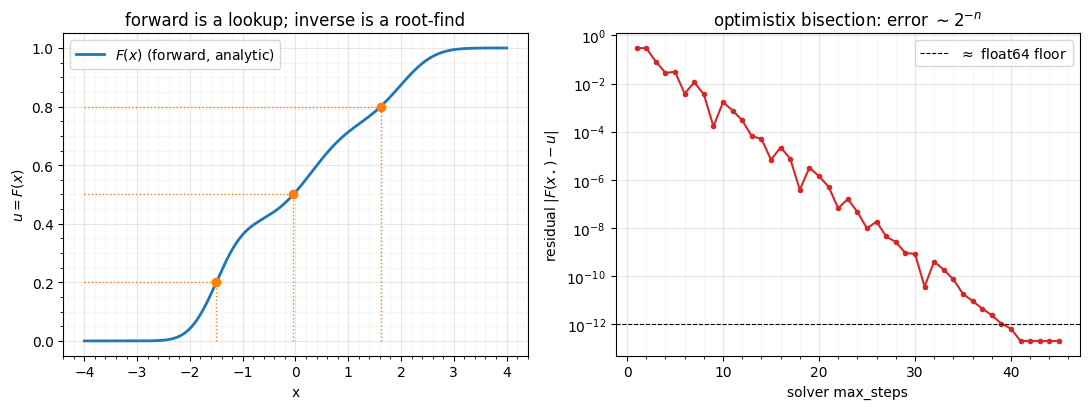

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

xg = jnp.linspace(-4, 4, 500)
axes[0].plot(xg, F_v(xg), color="tab:blue", lw=2, label="$F(x)$ (forward, analytic)")
for u in [0.2, 0.5, 0.8]:
    xr = float(invF(jnp.asarray(u)))
    axes[0].hlines(u, -4, xr, color="tab:orange", lw=1, ls=":")
    axes[0].vlines(xr, 0, u, color="tab:orange", lw=1, ls=":")
    axes[0].plot(xr, u, "o", color="tab:orange", ms=6)
axes[0].set(title="forward is a lookup; inverse is a root-find",
            xlabel="x", ylabel="$u = F(x)$")
axes[0].legend(loc="upper left")
style_ax(axes[0])

axes[1].semilogy(steps, err_vs_steps, "-o", color="tab:red", ms=3)
axes[1].axhline(1e-12, color="k", lw=0.8, ls="--", label=r"$\approx$ float64 floor")
axes[1].set(title=r"optimistix bisection: error $\sim 2^{-n}$",
            xlabel="solver max_steps", ylabel=r"residual $|F(x_\star) - u|$")
axes[1].legend()
style_ax(axes[1])
fig.tight_layout()

Left: inverting $F$ means reading the curve right-to-left — there is no formula,
so `optimistix` hunts for the $x$ that lands on each target $u$. Right: the
residual falls geometrically with the solver budget, hitting the float64 floor
in ~40 steps. Accurate and robust — but it is a *loop*. How to *differentiate*
that loop (and why naively unrolling it fails) is its own story, told in
[Part 1, notebook 03](../01_marginal_transforms/03_learnable_mixture_cdf.ipynb)
when we train a mixture-CDF.

## 3. The asymmetry on a real flow

`gauss_flows` builds its marginal layers from exactly this mixture-CDF, so a
whole flow inherits the asymmetry: `log_prob` runs the analytic forward maps,
while `sample` runs the bisection inverse inside every marginal layer. We time
both on the same flow (JIT-compiled and warmed up for a fair race).

In [4]:
import gauss_flows as gf

key = jr.key(0)
flow = gf.gaussianization_flow(key, n_dims=2, n_layers=6, n_components=8)
X = jnp.asarray(rng.standard_normal((5000, 2)))


@eqx.filter_jit
def logp(f, x):
    return f.log_prob(x)


@eqx.filter_jit
def samp(f, k):
    return f.sample(k, (5000,))


logp(flow, X).block_until_ready()           # warmup (compile)
samp(flow, key).block_until_ready()

t = time.perf_counter()
for _ in range(5):
    logp(flow, X).block_until_ready()
t_lp = (time.perf_counter() - t) / 5

t = time.perf_counter()
for i in range(5):
    samp(flow, jr.fold_in(key, i)).block_until_ready()
t_s = (time.perf_counter() - t) / 5

print(f"log_prob (forward, analytic)  : {t_lp * 1e3:6.2f} ms / 5000 pts")
print(f"sample   (inverse, bisection) : {t_s * 1e3:6.2f} ms / 5000 pts")
print(f"sample is {t_s / t_lp:.0f}x more expensive than log_prob")

log_prob (forward, analytic)  :  19.54 ms / 5000 pts
sample   (inverse, bisection) : 764.82 ms / 5000 pts
sample is 39x more expensive than log_prob


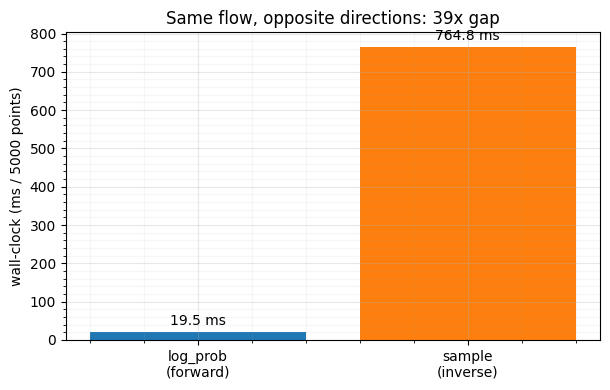

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4))
bars = ax.bar(["log_prob\n(forward)", "sample\n(inverse)"],
              [t_lp * 1e3, t_s * 1e3], color=["tab:blue", "tab:orange"])
ax.bar_label(bars, fmt="%.1f ms", padding=3)
ax.set(ylabel="wall-clock (ms / 5000 points)",
       title=f"Same flow, opposite directions: {t_s / t_lp:.0f}x gap")
style_ax(ax)
fig.tight_layout()

## 4. The parameterisation choice

The map $T$ and its inverse $T^{-1}$ describe the *same* flow — but we choose
**which one to store as the cheap, closed-form direction**. Whatever we store
cheaply, the *other* direction pays the iterative price.

- **Density-estimation flows** call `log_prob` constantly. Store the
  **forward** map cheaply → fast training, slow sampling. *This is what
  `gauss_flows` Gaussianization flows do, hence §3.*
- **Sampling / variational flows** call `sample` constantly. Store the
  **inverse** cheaply → fast sampling, slow density.

In `flowjax` the switch is one wrapper, `Invert`, which swaps a bijector's
forward and inverse.

In [6]:
from flowjax.bijections import Invert

b = gf.MixtureGaussianCDF(n_components=8, shape=(2,))
x = jnp.array([0.4, -0.7])
bi = Invert(b)  # forward and inverse swapped
print("Invert(b).transform == b.inverse :",
      bool(jnp.allclose(bi.transform(x), b.inverse(x))))
print("=> 'forward' and 'inverse' are a labelling choice, not a fixed property.")

Invert(b).transform == b.inverse : True
=> 'forward' and 'inverse' are a labelling choice, not a fixed property.


:::{note} Bridge: this *is* the MAF ↔ IAF story
Masked Autoregressive Flows (MAF) {cite}`papamakarios2017maf` and Inverse
Autoregressive Flows (IAF) {cite}`kingma2016iaf` are the same autoregressive
coupling {cite}`dinh2017realnvp` read in opposite directions. MAF stores the
density direction (parallel `log_prob`, sequential `sample`) — great for
density estimation. IAF stores the sampling direction (parallel `sample`,
sequential `log_prob`) — great as a variational posterior. We meet both as
*bridges* in [Part 5](../) and [Part 11](../); the trade-off is exactly the one
we measured in §3.
:::

## Recap

| concept | takeaway | in code |
|---|---|---|
| two directions | forward for density, inverse for sampling | `flow.log_prob` / `flow.sample` |
| mixture-CDF inverse | a monotone root-find | `optimistix.root_find` + `Bisection` |
| measured asymmetry | `sample` ≈ 39× `log_prob` for Gaussianization | timed, JIT-warmed |
| parameterisation | store the cheap direction; `Invert` swaps it | `flowjax.bijections.Invert` |
| differentiating the inverse | unrolling / one-step / adjoint | [Part 1, nb 03](../01_marginal_transforms/03_learnable_mixture_cdf.ipynb) |

**Next up.** We have been mapping *to* a standard Gaussian without asking why
that target. [03 — Why a standard Gaussian?](03_why_standard_gaussian.ipynb)
shows the three properties — maximum entropy, separability, trivial primitives
— that make $\mathcal{N}(0, I)$ the natural destination.